# Prompt Optimization: Actionability LLM Judge

In the previous tutorial, we built an **Actionability** LLM judge for generated PR review comments. We treated the judge prompt as an experiment artifact: we started with a naive prompt, measured it against expert labels, inspected disagreements, and manually wrote better prompt versions.

In this tutorial, we will keep the same evaluation goal but change the workflow.

Instead of hand-writing the next prompt hypothesis, we will use **Evidently PromptOptimizer** to turn expert labels and expert comments into an improved judge prompt.

The idea is simple:

1. start with a baseline judge prompt,
2. evaluate it against human labels,
3. let the optimizer inspect the mistakes and feedback,
4. generate an improved prompt,
5. test the selected prompt on held-out examples.

This is still an experiment loop. The difference is that the prompt update step is now automated and repeatable.


## 1. Dataset

We will use the same code review dataset as before.

Each row contains:

- a generated PR review comment,
- an expert label (`good` or `bad`),
- an expert comment explaining the label.

The expert comment is especially useful for prompt optimization. It tells the optimizer *why* a review was accepted or rejected, not just which label it received.


In [9]:
# If needed:
# !pip install evidently openai pandas scikit-learn

# Import libraries
import json
import os
import re
from pathlib import Path

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

import numpy as np
import pandas as pd
from openai import OpenAI

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split

from evidently import Dataset, DataDefinition, LLMClassification
from evidently.descriptors import LLMEval
from evidently.llm.optimization import PromptOptimizer
from evidently.llm.templates import BinaryClassificationPromptTemplate


In [10]:
# Load human-reviewed examples
DATA_PATH = Path("data/code_review.csv")

raw_df = pd.read_csv(DATA_PATH)

df = raw_df.rename(columns={
    "Generated review": "review",
    "Expert label": "expert_label",
    "Expert comment": "expert_comment",
})

df["id"] = np.arange(1, len(df) + 1)
df["expert_label"] = df["expert_label"].str.strip().str.lower()
df["expert_comment"] = df["expert_comment"].fillna("")

df = df[["id", "review", "expert_label", "expert_comment"]]

print(f"Total examples: {len(df)}")
df.head()


Total examples: 50


,id,review,expert_label,expert_comment
0,1,"This implementation appears to work, but the a...",bad,"The tone is slighly condescending, no actionab..."
1,2,Great job! Keep it up!,bad,Not actionable
2,3,It would be advisable to think about modularit...,bad,"there is a suggestion, but no real guidance"
3,4,"You’ve structured the class very well, and the...",good,"Good tone, actionable"
4,5,Great job! This is clean and well-organized. T...,bad,Pure praise


In [11]:
label_summary = (
    df["expert_label"]
    .value_counts()
    .rename_axis("expert_label")
    .reset_index(name="count")
)

label_summary["share_%"] = (
    label_summary["count"] / label_summary["count"].sum() * 100
).round(1)

label_summary


,expert_label,count,share_%
0,bad,27,54.0
1,good,23,46.0


## 2. Development and Test Split

We will use the development set for prompt optimization. The test set stays untouched until the final check.

This matters because prompt optimization can overfit just like manual prompt iteration can. If we let the optimizer see every example, we would have no honest way to check whether the final prompt generalizes.


In [12]:
dev_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["expert_label"],
)

dev_df = dev_df.sort_values("id").reset_index(drop=True)
test_df = test_df.sort_values("id").reset_index(drop=True)

print(f"Development examples: {len(dev_df)}")
print(f"Test examples: {len(test_df)}")


Development examples: 35
Test examples: 15


## 3. Evidently Setup

Evidently needs to know which column is the input text, which column is the target label, and which column contains expert reasoning.

We will map:

- `review` as the judge input,
- `expert_label` as the target,
- `expert_comment` as the human reasoning.


In [13]:
# Evidently classes are imported in the first setup cell.
# This cell keeps the tutorial section boundary explicit.

def make_evidently_dataset(dataframe):
    data_definition = DataDefinition(
        text_columns=["review", "expert_comment"],
        categorical_columns=["expert_label"],
        llm=LLMClassification(
            input="review",
            target="expert_label",
            reasoning="expert_comment",
        ),
    )

    return Dataset.from_pandas(
        dataframe[["id", "review", "expert_label", "expert_comment"]].copy(),
        data_definition=data_definition,
    )


dev_dataset = make_evidently_dataset(dev_df)
test_dataset = make_evidently_dataset(test_df)

dev_dataset


## 4. Baseline Judge Prompt

We start with a deliberately simple criteria prompt. This is the kind of prompt you might write before looking closely at the edge cases.

Evidently provides the shared judge structure through `BinaryClassificationPromptTemplate`: categories, output format, reasoning, and classification instructions. We only define the criteria.


In [14]:
RUN_LIVE_LLM = True
RUN_OPTIMIZATION = True
RUN_FINAL_EVALUATION = True

PROVIDER = "openai"
MODEL = "gpt-4o-mini"
OPTIMIZER_REPETITIONS = 5

print(f"Provider: {PROVIDER}")
print(f"Model: {MODEL}")
print(f"Run live LLM calls: {RUN_LIVE_LLM}")
print(f"Run prompt optimization: {RUN_OPTIMIZATION}")


Provider: openai
Model: gpt-4o-mini
Run live LLM calls: True
Run prompt optimization: True


In [15]:
BASELINE_CRITERIA = '''
A review is GOOD when it is actionable and constructive.
A review is BAD when it is non-actionable, vague, overly critical, or pure praise.
'''.strip()


def make_actionability_template(criteria):
    return BinaryClassificationPromptTemplate(
        pre_messages=[
            (
                "system",
                "You are evaluating generated pull request review comments for actionability.",
            )
        ],
        criteria=criteria,
        target_category="bad",
        non_target_category="good",
        uncertainty="unknown",
        include_reasoning=True,
    )


def make_actionability_judge(criteria, alias="Actionability Judge"):
    return LLMEval(
        alias=alias,
        provider=PROVIDER,
        model=MODEL,
        column_name="review",
        template=make_actionability_template(criteria),
    )


baseline_template = make_actionability_template(BASELINE_CRITERIA)
baseline_judge = make_actionability_judge(BASELINE_CRITERIA, alias="Baseline Actionability Judge")

print(BASELINE_CRITERIA)

A review is GOOD when it is actionable and constructive.
A review is BAD when it is non-actionable, vague, overly critical, or pure praise.


## 5. Baseline Evaluation

Before optimizing anything, we measure the baseline judge on the development set.

This is not required by the optimizer, but it makes the experiment easier to understand. We want to see how much value the optimization loop adds.


In [16]:
LABELS = ["bad", "good"]

def parse_json_or_label(content):
    try:
        result = json.loads(content)
    except json.JSONDecodeError:
        result = {}

    label = str(
        result.get("category")
        or result.get("predicted_label")
        or result.get("label")
        or ""
    ).strip().lower()

    if label not in LABELS:
        match = re.search(r"\b(good|bad)\b", content.lower())
        label = match.group(1) if match else "bad"

    reason = str(
        result.get("reasoning")
        or result.get("reason")
        or ""
    ).strip()

    return label, reason


def predict_with_openai_template(review, template, model=MODEL):
    client = OpenAI()
    messages = [
        {"role": message.role, "content": message.content}
        for message in template.get_messages({"input": review})
    ]

    response = client.chat.completions.create(
        model=model,
        messages=messages,
        response_format={"type": "json_object"},
    )

    content = response.choices[0].message.content
    label, reason = parse_json_or_label(content)

    return {
        "predicted_label": label,
        "judge_reason": reason,
        "raw_response": content,
    }


def predict_with_demo_rules(review):
    text = review.lower()
    positive_only = any(phrase in text for phrase in ["great job", "keep it up", "nice work"])
    concrete_cue = any(
        cue in text
        for cue in [
            "because", "for example", "line", "function", "method", "class",
            "add", "remove", "rename", "extract", "handle", "check", "test",
        ]
    )
    vague_cue = any(
        cue in text
        for cue in ["consider", "think about", "best practices", "more efficient", "improve this"]
    )

    if positive_only or (vague_cue and not concrete_cue):
        label = "bad"
        reason = "Demo rules detected praise or vague advice without concrete guidance."
    elif concrete_cue:
        label = "good"
        reason = "Demo rules detected a concrete implementation cue."
    else:
        label = "bad"
        reason = "Demo rules did not find enough specific guidance."

    return {
        "predicted_label": label,
        "judge_reason": reason,
        "raw_response": "",
    }


def run_template_judge(dataframe, template, judge_version, dataset_split):
    rows = []

    for _, row in dataframe.iterrows():
        if RUN_LIVE_LLM:
            prediction = predict_with_openai_template(row["review"], template)
        else:
            prediction = predict_with_demo_rules(row["review"])

        rows.append({
            "id": row["id"],
            "review": row["review"],
            "expert_label": row["expert_label"],
            "expert_comment": row["expert_comment"],
            "predicted_label": prediction["predicted_label"],
            "judge_reason": prediction["judge_reason"],
            "raw_response": prediction["raw_response"],
            "judge_version": judge_version,
            "dataset_split": dataset_split,
        })

    return pd.DataFrame(rows)


In [17]:
def summarize_predictions(predictions, judge_version, short_description, dataset_split):
    y_true = predictions["expert_label"]
    y_pred = predictions["predicted_label"]

    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=LABELS,
        average="macro",
        zero_division=0,
    )

    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    false_good = int(((y_true == "bad") & (y_pred == "good")).sum())
    false_bad = int(((y_true == "good") & (y_pred == "bad")).sum())

    return {
        "judge_version": judge_version,
        "short_description": short_description,
        "source": "manual_baseline" if judge_version == "baseline" else "evidently_optimizer",
        "provider": PROVIDER if RUN_LIVE_LLM else "demo",
        "model": MODEL if RUN_LIVE_LLM else "rule-based-demo",
        "dataset_split": dataset_split,
        "n_examples": len(predictions),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": macro_f1,
        "false_good": false_good,
        "false_bad": false_bad,
        "confusion_matrix": cm.tolist(),
    }


def show_disagreements(predictions):
    columns = [
        "id",
        "review",
        "expert_label",
        "predicted_label",
        "expert_comment",
        "judge_reason",
    ]

    return (
        predictions[predictions["expert_label"] != predictions["predicted_label"]]
        [columns]
        .sort_values("id")
        .reset_index(drop=True)
    )


In [18]:
baseline_dev_predictions = run_template_judge(
    dev_df,
    baseline_template,
    judge_version="baseline",
    dataset_split="dev",
)

baseline_dev_summary = summarize_predictions(
    baseline_dev_predictions,
    judge_version="baseline",
    short_description="Simple actionable and constructive criteria",
    dataset_split="dev",
)

pd.DataFrame([baseline_dev_summary]).drop(columns=["confusion_matrix"])


,judge_version,short_description,source,provider,model,dataset_split,n_examples,accuracy,macro_precision,macro_recall,macro_f1,false_good,false_bad
0,baseline,Simple actionable and constructive criteria,manual_baseline,openai,gpt-4o-mini,dev,35,0.828571,0.863636,0.842105,0.827303,6,0


In [19]:
show_disagreements(baseline_dev_predictions)

,id,review,expert_label,predicted_label,expert_comment,judge_reason
0,7,There is too much complexity in this function....,bad,good,there is some subtance but too sounds too harsh,"The review provides specific, actionable feedb..."
1,25,"The approach taken here is functional, althoug...",bad,good,"vague, suggests improvement without naming a s...",The review provides constructive feedback by a...
2,27,"This part could be optimized, though it’s not ...",bad,good,"sounds like helpful feedback, but gives no con...",The comment suggests an optimization while ack...
3,28,This structure is slightly unconventional. You...,bad,good,not concrete,The comment identifies a specific aspect of th...
4,29,The naming here is a bit nonstandard. It might...,bad,good,"i don't want it to pick on names, this adds no...",The comment provides a specific suggestion reg...
5,33,Looks good! Possibly worth reviewing the loop ...,bad,good,suggests doubt with no basis or detail.,The comment provides positive feedback while a...


## 6. Prompt Optimization

Now we replace the manual prompt-editing step with Evidently PromptOptimizer.

The optimizer uses the development dataset and the baseline judge as input. With the feedback strategy, it looks at incorrect classifications and uses the expert comments to propose improved criteria.

We use accuracy as the optimization scorer because this is a binary classification judge and the dataset has expert labels.


In [20]:
if RUN_OPTIMIZATION:
    optimizer = PromptOptimizer(
        "actionability_judge_prompt_optimization",
        strategy="feedback",
        verbose=True,
    )

    optimizer.run(
        executor=baseline_judge,
        scorer="accuracy",
        dataset=dev_dataset,
        repetitions=OPTIMIZER_REPETITIONS,
    )
else:
    optimizer = None
    print("Set RUN_OPTIMIZATION = True to run Evidently PromptOptimizer.")


[0] Executed prompt 'A review is GOOD when it is actionable a...', got predictions(35) reasoning(35)
[0] Prompt scored: AccuracyScorer: {'train': 0.7857142857142857, 'test': 0.8571428571428571, 'val': 0.7857142857142857}


Task exception was never retrieved
future: <Task finished name='Task-240' coro=<AsyncClient.aclose() done, defined at /opt/homebrew/Caskroom/miniconda/base/envs/pd3/lib/python3.13/site-packages/httpx/_client.py:1978> exception=RuntimeError('Event loop is closed')>
Traceback (most recent call last):
  File "/opt/homebrew/Caskroom/miniconda/base/envs/pd3/lib/python3.13/site-packages/httpx/_client.py", line 1985, in aclose
    await self._transport.aclose()
  File "/opt/homebrew/Caskroom/miniconda/base/envs/pd3/lib/python3.13/site-packages/httpx/_transports/default.py", line 406, in aclose
    await self._pool.aclose()
  File "/opt/homebrew/Caskroom/miniconda/base/envs/pd3/lib/python3.13/site-packages/httpcore/_async/connection_pool.py", line 353, in aclose
    await self._close_connections(closing_connections)
  File "/opt/homebrew/Caskroom/miniconda/base/envs/pd3/lib/python3.13/site-packages/httpcore/_async/connection_pool.py", line 345, in _close_connections
    await connection.aclose

[1] Executed prompt 'A review is GOOD when it is actionable a...', got predictions(35) reasoning(35)
[1] Prompt scored: AccuracyScorer: {'train': 0.7142857142857143, 'test': 1.0, 'val': 0.7857142857142857}
[2] Executed prompt 'A review is GOOD when it is actionable a...', got predictions(35) reasoning(35)
[2] Prompt scored: AccuracyScorer: {'train': 0.7857142857142857, 'test': 1.0, 'val': 0.7857142857142857}
[3] Executed prompt 'A review is GOOD when it is actionable a...', got predictions(35) reasoning(35)
[3] Prompt scored: AccuracyScorer: {'train': 0.7857142857142857, 'test': 1.0, 'val': 0.7857142857142857}
[4] Executed prompt 'A review is GOOD when it is actionable a...', got predictions(35) reasoning(35)
[4] Prompt scored: AccuracyScorer: {'train': 0.7142857142857143, 'test': 0.8571428571428571, 'val': 0.7857142857142857}
[1] Prompt 'A review is GOOD when it is actionable a...' optimized to 'A review is GOOD when it provides action...'


Task exception was never retrieved
future: <Task finished name='Task-386' coro=<AsyncClient.aclose() done, defined at /opt/homebrew/Caskroom/miniconda/base/envs/pd3/lib/python3.13/site-packages/httpx/_client.py:1978> exception=RuntimeError('Event loop is closed')>
Traceback (most recent call last):
  File "/opt/homebrew/Caskroom/miniconda/base/envs/pd3/lib/python3.13/site-packages/httpx/_client.py", line 1985, in aclose
    await self._transport.aclose()
  File "/opt/homebrew/Caskroom/miniconda/base/envs/pd3/lib/python3.13/site-packages/httpx/_transports/default.py", line 406, in aclose
    await self._pool.aclose()
  File "/opt/homebrew/Caskroom/miniconda/base/envs/pd3/lib/python3.13/site-packages/httpcore/_async/connection_pool.py", line 353, in aclose
    await self._close_connections(closing_connections)
  File "/opt/homebrew/Caskroom/miniconda/base/envs/pd3/lib/python3.13/site-packages/httpcore/_async/connection_pool.py", line 345, in _close_connections
    await connection.aclose

[1] Executed prompt 'A review is GOOD when it provides action...', got predictions(35) reasoning(35)
[1] Prompt scored: AccuracyScorer: {'train': 0.7857142857142857, 'test': 1.0, 'val': 0.7857142857142857}
[1] Optimization run finished in 2 steps with best scores {'train': 0.7857142857142857, 'test': 1.0, 'val': 0.7857142857142857}.
[3] Prompt 'A review is GOOD when it is actionable a...' optimized to 'A review is GOOD when it provides specif...'
[3] Executed prompt 'A review is GOOD when it provides specif...', got predictions(35) reasoning(35)
[3] Prompt scored: AccuracyScorer: {'train': 0.7857142857142857, 'test': 1.0, 'val': 0.7857142857142857}
[3] Optimization run finished in 2 steps with best scores {'train': 0.7857142857142857, 'test': 1.0, 'val': 0.7857142857142857}.
[4] Prompt 'A review is GOOD when it is actionable a...' optimized to 'A review is GOOD when it provides specif...'
[4] Executed prompt 'A review is GOOD when it provides specif...', got predictions(35) reasoning(3

Task exception was never retrieved
future: <Task finished name='Task-534' coro=<AsyncClient.aclose() done, defined at /opt/homebrew/Caskroom/miniconda/base/envs/pd3/lib/python3.13/site-packages/httpx/_client.py:1978> exception=RuntimeError('Event loop is closed')>
Traceback (most recent call last):
  File "/opt/homebrew/Caskroom/miniconda/base/envs/pd3/lib/python3.13/site-packages/httpx/_client.py", line 1985, in aclose
    await self._transport.aclose()
  File "/opt/homebrew/Caskroom/miniconda/base/envs/pd3/lib/python3.13/site-packages/httpx/_transports/default.py", line 406, in aclose
    await self._pool.aclose()
  File "/opt/homebrew/Caskroom/miniconda/base/envs/pd3/lib/python3.13/site-packages/httpcore/_async/connection_pool.py", line 353, in aclose
    await self._close_connections(closing_connections)
  File "/opt/homebrew/Caskroom/miniconda/base/envs/pd3/lib/python3.13/site-packages/httpcore/_async/connection_pool.py", line 345, in _close_connections
    await connection.aclose

[4] Prompt 'A review is GOOD when it provides specif...' optimized to 'A review is GOOD when it provides specif...'
[4] Executed prompt 'A review is GOOD when it provides specif...', got predictions(35) reasoning(35)
[4] Prompt scored: AccuracyScorer: {'train': 0.8571428571428571, 'test': 1.0, 'val': 0.9285714285714286}
[4] Optimization run finished in 3 steps with best scores {'train': 0.8571428571428571, 'test': 1.0, 'val': 0.9285714285714286}.
[2] Prompt 'A review is classified as GOOD when it p...' optimized to 'A review is classified as GOOD when it p...'
[2] Executed prompt 'A review is classified as GOOD when it p...', got predictions(35) reasoning(35)
[2] Prompt scored: AccuracyScorer: {'train': 0.8571428571428571, 'test': 1.0, 'val': 1.0}
[2] Optimization run finished in 3 steps with best scores {'train': 0.8571428571428571, 'test': 1.0, 'val': 1.0}.


In [21]:
if optimizer is not None:
    print("Best score:", optimizer.best_score())
    print()
    print(optimizer.best_prompt())
else:
    CACHED_OPTIMIZED_CRITERIA = '''
A review is classified as GOOD when it provides actionable, constructive feedback
that clearly guides the recipient toward improvement. It should identify a concrete
issue, behavior, or improvement area and provide a specific next step, check, or
change. A review is classified as BAD when it is non-actionable, overly critical,
too vague, mostly praise, or lacks enough specificity to guide the developer.
'''.strip()

    print(CACHED_OPTIMIZED_CRITERIA)


Best score: {'train': 0.8571428571428571, 'test': 1.0, 'val': 1.0}

A review is classified as GOOD when it provides specific, actionable, and constructive feedback that can lead to improvements in the subject being reviewed. It should include clear recommendations or steps that can be taken, along with explanations of the benefits of those suggestions. A review is classified as BAD when it is non-actionable, vague, overly critical, or merely expresses praise without offering suggestions. Bad reviews often lack detail or direction, and do not identify concrete steps for improvement. When evaluating a review, consider the level of specificity, the clarity of recommendations, and the overall intent to help improve the subject matter.


In [22]:
if optimizer is not None:
    optimizer.print_stats()

Optimization statistics:
Seed: None
Dataset train: 14, val: 14, test: 7
Runs: 5
Total time: 25.90s
Total steps: 7
Total input tokens: 3564
Total output tokens: 556
Best prompt (score {'train': 0.8571428571428571, 'test': 1.0, 'val': 1.0}): A review is classified as GOOD when it provides specific, actionable, and constructive feedback that can lead to improvements in the subject being reviewed. It should include clear recommendations or steps that can be taken, along with explanations of the benefits of those suggestions. A review is classified as BAD when it is non-actionable, vague, overly critical, or merely expresses praise without offering suggestions. Bad reviews often lack detail or direction, and do not identify concrete steps for improvement. When evaluating a review, consider the level of specificity, the clarity of recommendations, and the overall intent to help improve the subject matter.
Detailed run statistics:
Optimizer Run [0], seed [None]
Steps: 1
Time: 18.9s
Input toke

## 7. Build The Optimized Judge

The optimizer gives us two useful artifacts:

- `best_prompt()` for human inspection,
- `best_executor()` for reuse in evaluations.

If we do not run the optimizer in this notebook session, we fall back to a cached criteria string so the rest of the tutorial remains readable.


In [23]:
if optimizer is not None:
    optimized_judge = optimizer.best_executor()
    optimized_template = optimized_judge.template
    optimized_prompt_text = optimizer.best_prompt()
else:
    optimized_template = make_actionability_template(CACHED_OPTIMIZED_CRITERIA)
    optimized_prompt_text = CACHED_OPTIMIZED_CRITERIA

print(optimized_prompt_text)

A review is classified as GOOD when it provides specific, actionable, and constructive feedback that can lead to improvements in the subject being reviewed. It should include clear recommendations or steps that can be taken, along with explanations of the benefits of those suggestions. A review is classified as BAD when it is non-actionable, vague, overly critical, or merely expresses praise without offering suggestions. Bad reviews often lack detail or direction, and do not identify concrete steps for improvement. When evaluating a review, consider the level of specificity, the clarity of recommendations, and the overall intent to help improve the subject matter.


## 8. Optimized Judge Development Check

Before moving to the held-out test set, we run the selected optimized prompt on the development examples.

This gives us a comparable experiment row: the metrics come from actual predictions, just like the baseline row. We do not use `optimizer.best_score()` directly in the experiment table because it can return optimizer metadata instead of a single scalar metric.


In [24]:
if RUN_FINAL_EVALUATION:
    optimized_dev_predictions = run_template_judge(
        dev_df,
        optimized_template,
        judge_version="optimized",
        dataset_split="dev",
    )

    optimized_dev_summary = summarize_predictions(
        optimized_dev_predictions,
        judge_version="optimized",
        short_description="Prompt selected by Evidently PromptOptimizer",
        dataset_split="dev",
    )

    pd.DataFrame([optimized_dev_summary]).drop(columns=["confusion_matrix"])
else:
    optimized_dev_predictions = pd.DataFrame()
    optimized_dev_summary = None
    print("Set RUN_FINAL_EVALUATION = True to evaluate the optimized judge on the development set.")


## 9. Final Held-Out Test

The development set was used to optimize the prompt. The test set was not.

Now we run the selected judge on the held-out examples to check whether the optimized criteria generalize beyond the examples used during optimization.


In [25]:
if RUN_FINAL_EVALUATION:
    optimized_test_predictions = run_template_judge(
        test_df,
        optimized_template,
        judge_version="optimized",
        dataset_split="test",
    )

    optimized_test_summary = summarize_predictions(
        optimized_test_predictions,
        judge_version="optimized",
        short_description="Prompt selected by Evidently PromptOptimizer",
        dataset_split="test",
    )

    pd.DataFrame([optimized_test_summary]).drop(columns=["confusion_matrix"])
else:
    optimized_test_predictions = pd.DataFrame()
    optimized_test_summary = None
    print("Set RUN_FINAL_EVALUATION = True to evaluate the optimized judge on the test set.")

In [26]:
if RUN_FINAL_EVALUATION:
    show_disagreements(optimized_test_predictions)

## 10. Experiment Log

We keep the same habit from the previous tutorial: every judge run becomes a row in an experiment log.

For this tutorial, the important distinction is the `source` column:

- `manual_baseline`: a prompt we wrote ourselves,
- `evidently_optimizer`: a prompt selected by the optimization loop.


In [27]:
experiment_rows = [baseline_dev_summary]

if optimized_dev_summary is not None:
    experiment_rows.append(optimized_dev_summary)

if optimized_test_summary is not None:
    experiment_rows.append(optimized_test_summary)

experiment_runs = pd.DataFrame(experiment_rows)

display_columns = [
    "judge_version",
    "source",
    "dataset_split",
    "n_examples",
    "accuracy",
    "macro_f1",
    "false_good",
    "false_bad",
    "short_description",
]

experiment_runs[display_columns]

,judge_version,source,dataset_split,n_examples,accuracy,macro_f1,false_good,false_bad,short_description
0,baseline,manual_baseline,dev,35,0.828571,0.827303,6,0,Simple actionable and constructive criteria
1,optimized,evidently_optimizer,dev,35,0.971429,0.971335,1,0,Prompt selected by Evidently PromptOptimizer
2,optimized,evidently_optimizer,test,15,1.000000,1.000000,0,0,Prompt selected by Evidently PromptOptimizer


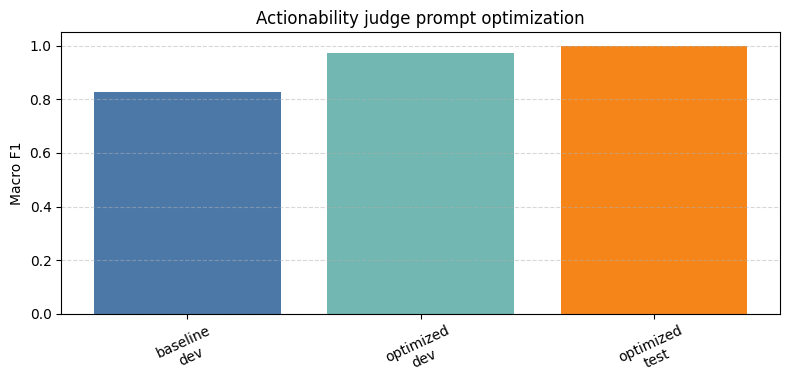

In [28]:
plot_df = experiment_runs.copy()
plot_df["run_label"] = plot_df["judge_version"] + "\n" + plot_df["dataset_split"]

if plt is None:
    experiment_runs[display_columns]
else:
    fig, ax = plt.subplots(figsize=(8, 4))

    colors = ["#4C78A8", "#72B7B2", "#F58518", "#54A24B"]
    bar_colors = [colors[i % len(colors)] for i in range(len(plot_df))]

    ax.bar(plot_df["run_label"], plot_df["macro_f1"], color=bar_colors)
    ax.set_ylabel("Macro F1")
    ax.set_title("Actionability judge prompt optimization")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.tick_params(axis="x", rotation=25)

    plt.tight_layout()
    plt.show()

## 11. Save The Optimized Judge

The selected judge should be saved as a reusable artifact.

If the optimizer ran, we save the optimized Evidently template as YAML. If not, we save the cached criteria as a small JSON-like dictionary so the notebook still documents the intended production artifact.


In [29]:
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

if optimizer is not None:
    template_path = ARTIFACT_DIR / "actionability_judge_optimized_template.yaml"
    optimized_template.dump(str(template_path))

    final_judge = {
        "judge_version": "optimized",
        "source": "evidently_optimizer",
        "provider": PROVIDER,
        "model": MODEL,
        "template_path": str(template_path),
        "prompt": optimized_prompt_text,
    }
else:
    final_judge = {
        "judge_version": "cached_optimized",
        "source": "cached_example",
        "provider": PROVIDER,
        "model": MODEL,
        "criteria": optimized_prompt_text,
    }

final_judge


{'judge_version': 'optimized',
 'source': 'evidently_optimizer',
 'provider': 'openai',
 'model': 'gpt-4o-mini',
 'template_path': 'artifacts/actionability_judge_optimized_template.yaml',
 'prompt': 'A review is classified as GOOD when it provides specific, actionable, and constructive feedback that can lead to improvements in the subject being reviewed. It should include clear recommendations or steps that can be taken, along with explanations of the benefits of those suggestions. A review is classified as BAD when it is non-actionable, vague, overly critical, or merely expresses praise without offering suggestions. Bad reviews often lack detail or direction, and do not identify concrete steps for improvement. When evaluating a review, consider the level of specificity, the clarity of recommendations, and the overall intent to help improve the subject matter.'}

In [30]:
# Optional: export the experiment log for later comparison.
# Uncomment when you want to save a local CSV.
# experiment_runs.to_csv("actionability_prompt_optimization_runs.csv", index=False)

## Conclusion

In the manual workflow, the team had to inspect errors and write the next judge prompt by hand.

With prompt optimization, the team still needs high-quality expert labels and comments, but the prompt-writing step becomes more systematic. The optimizer can turn examples of human judgment into a reusable actionability judge prompt.

This does not remove human review from the process. It moves human effort to the highest-leverage place: labeling examples, explaining decisions, and validating the final judge.
